# 09 — Report Exports and Publication Figures

Notebook này tạo **bảng dữ liệu xuất** và **figure dùng trong báo cáo đề tài** từ kết quả rolling-DES B0/B3/B4/B6.

**Evidence guard:** notebook ưu tiên `experiments/paired_30/replication_metrics.csv`. Nếu final experiment chưa tồn tại, notebook tự fallback sang `experiments/smoke_3rep/replication_metrics.csv` **chỉ để kiểm tra pipeline và bố cục**. Các export fallback được gắn nhãn `engineering_preview` và không được dùng làm kết quả khoa học cuối cùng.

Output được ghi vào `report_exports/<evidence_mode>/` dưới dạng CSV + PNG/SVG và `manifest.json` để truy vết nguồn.

## 1. Context & Methods

### Key assumptions

- Statistical unit là **paired replication**, không phải từng incident.
- B6 được so với B0/B3/B4 trên cùng `(scenario_id, replication_id)` và common-random design.
- B0 là naive reference và không enforce toàn bộ hard feasibility của B3/B4/B6; vì vậy B6–B0 chủ yếu mang tính bối cảnh.
- B6–B3 và B6–B4 là các incremental comparisons phù hợp hơn để trình bày giá trị tích hợp.
- Full Pareto frontier và controlled ablation nằm ngoài notebook này nếu experiment tương ứng chưa được chạy.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repository root robustly whether launched from repo root or notebooks/.
def find_repo_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / 'configs' / 'experiment_30_paired.json').exists():
            return p
    raise FileNotFoundError('Cannot locate repository root containing configs/experiment_30_paired.json')

ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FINAL_METRICS = ROOT / 'experiments' / 'paired_30' / 'replication_metrics.csv'
SMOKE_METRICS = ROOT / 'experiments' / 'smoke_3rep' / 'replication_metrics.csv'

if FINAL_METRICS.exists():
    SOURCE_METRICS = FINAL_METRICS
    EVIDENCE_MODE = 'final_paired30'
    IS_FINAL_SOURCE = True
else:
    SOURCE_METRICS = SMOKE_METRICS
    EVIDENCE_MODE = 'engineering_preview_smoke3rep'
    IS_FINAL_SOURCE = False

if not SOURCE_METRICS.exists():
    raise FileNotFoundError('Neither paired_30 nor smoke_3rep replication_metrics.csv exists.')

EXPORT_DIR = ROOT / 'report_exports' / EVIDENCE_MODE
TABLE_DIR = EXPORT_DIR / 'tables'
FIGURE_DIR = EXPORT_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (8.4, 5.2),
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.22,
})

print('Repository:', ROOT)
print('Source:', SOURCE_METRICS.relative_to(ROOT))
print('Evidence mode:', EVIDENCE_MODE)
if not IS_FINAL_SOURCE:
    print('WARNING: smoke_3rep is engineering evidence only; do not use numerical results as final paper evidence.')


Repository: /Users/nguyenminhtruc-mac/Developer/Research/siev-e-ambulance-research-operations
Source: experiments/smoke_3rep/replication_metrics.csv
Evidence mode: engineering_preview_smoke3rep


## 2. Data & Evidence Validation

In [2]:
metrics = pd.read_csv(SOURCE_METRICS)

required = {'scenario_id', 'replication_id', 'policy_id', 'random_seed', 'common_random_group'}
missing = required - set(metrics.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

expected_policies = {'B0', 'B3', 'B4', 'B6'}
observed_policies = set(metrics['policy_id'].astype(str))
if not expected_policies.issubset(observed_policies):
    raise ValueError(f'Expected policies {sorted(expected_policies)}, found {sorted(observed_policies)}')

coverage = (
    metrics.groupby(['scenario_id', 'policy_id'])['replication_id']
    .nunique()
    .rename('n_replications')
    .reset_index()
)
coverage.to_csv(TABLE_DIR / '00_coverage.csv', index=False)

pair_audit = (
    metrics.groupby(['scenario_id', 'replication_id'])
    .agg(
        policy_count=('policy_id', 'nunique'),
        seed_count=('random_seed', 'nunique'),
        common_random_group_count=('common_random_group', 'nunique'),
    )
    .reset_index()
)
pair_audit['complete_pair'] = (
    (pair_audit['policy_count'] == 4)
    & (pair_audit['seed_count'] == 1)
    & (pair_audit['common_random_group_count'] == 1)
)
pair_audit.to_csv(TABLE_DIR / '00_pairing_audit.csv', index=False)

coverage


,scenario_id,policy_id,n_replications
0,high_demand,B0,3
1,high_demand,B3,3
2,high_demand,B4,3
3,high_demand,B6,3
4,normal,B0,3
5,normal,B3,3
6,normal,B4,3
7,normal,B6,3
8,peak,B0,3
9,peak,B3,3


In [3]:
run_summary_path = SOURCE_METRICS.parent / 'run_summary.json'
runtime_validation_path = SOURCE_METRICS.parent / 'runtime_validation.json'
run_summary = json.loads(run_summary_path.read_text(encoding='utf-8')) if run_summary_path.exists() else {}
runtime_validation = json.loads(runtime_validation_path.read_text(encoding='utf-8')) if runtime_validation_path.exists() else {}

final_evidence_ready = bool(
    IS_FINAL_SOURCE
    and run_summary.get('final_evidence_ready', False)
    and pair_audit['complete_pair'].all()
)

validation_status = pd.DataFrame([
    {'check': 'source_is_paired_30', 'pass': IS_FINAL_SOURCE},
    {'check': 'all_present_pairs_complete', 'pass': bool(pair_audit['complete_pair'].all())},
    {'check': 'run_summary_final_evidence_ready', 'pass': bool(run_summary.get('final_evidence_ready', False))},
    {'check': 'final_evidence_ready_combined', 'pass': final_evidence_ready},
])
validation_status.to_csv(TABLE_DIR / '00_validation_status.csv', index=False)
validation_status


,check,pass
0,source_is_paired_30,False
1,all_present_pairs_complete,True
2,run_summary_final_evidence_ready,False
3,final_evidence_ready_combined,False


## 3. Export Tables

In [4]:
KEY_METRICS = [
    'served_rate',
    'feasible_rate_overall',
    'SLA_pass_rate',
    'avg_response_time_min',
    'P95_response_P1',
    'time_to_compatible_hospital',
    'unserved_count',
    'SOC_violation_count',
    'hospital_capacity_violations',
    'hospital_capability_violations',
    'avg_solver_time_sec',
    'max_mip_gap',
]
KEY_METRICS = [m for m in KEY_METRICS if m in metrics.columns]

summary_rows = []
for (scenario, policy), g in metrics.groupby(['scenario_id', 'policy_id'], sort=True):
    for metric in KEY_METRICS:
        x = pd.to_numeric(g[metric], errors='coerce').dropna()
        if x.empty:
            continue
        summary_rows.append({
            'scenario_id': scenario,
            'policy_id': policy,
            'metric': metric,
            'n_replications': int(x.shape[0]),
            'mean': float(x.mean()),
            'std': float(x.std(ddof=1)) if len(x) > 1 else np.nan,
            'median': float(x.median()),
            'min': float(x.min()),
            'max': float(x.max()),
        })

policy_summary = pd.DataFrame(summary_rows)
policy_summary.to_csv(TABLE_DIR / '01_policy_scenario_summary.csv', index=False)
policy_summary.head(12)


,scenario_id,policy_id,metric,n_replications,mean,std,median,min,max
0,high_demand,B0,served_rate,3,0.980000,0.010000,0.980000,0.970000,0.990000
1,high_demand,B0,feasible_rate_overall,3,0.256667,0.020817,0.250000,0.240000,0.280000
2,high_demand,B0,SLA_pass_rate,3,0.900000,0.045826,0.890000,0.860000,0.950000
3,high_demand,B0,avg_response_time_min,3,6.061428,0.378841,6.065144,5.680742,6.438398
4,high_demand,B0,P95_response_P1,3,13.097696,2.030409,12.203946,11.667482,15.421662
5,high_demand,B0,time_to_compatible_hospital,3,28.512531,0.898686,28.628294,27.561572,29.347726
6,high_demand,B0,unserved_count,3,2.000000,1.000000,2.000000,1.000000,3.000000
7,high_demand,B0,SOC_violation_count,3,0.000000,0.000000,0.000000,0.000000,0.000000
8,high_demand,B0,hospital_capacity_violations,3,54.666667,2.081666,54.000000,53.000000,57.000000
9,high_demand,B0,hospital_capability_violations,3,44.333333,4.163332,43.000000,41.000000,49.000000


In [5]:
from src.analyze_paired import HIGHER_BETTER, LOWER_BETTER, bootstrap_ci

paired_metrics = [m for m in KEY_METRICS if m in (HIGHER_BETTER | LOWER_BETTER)]
paired_rows = []
for scenario, sdf in metrics.groupby('scenario_id'):
    wide = sdf.pivot(index='replication_id', columns='policy_id')
    for base in ['B0', 'B3', 'B4']:
        for metric in paired_metrics:
            try:
                ref = wide[(metric, 'B6')]
                cmp = wide[(metric, base)]
            except KeyError:
                continue
            paired = pd.concat([ref, cmp], axis=1, keys=['B6', base]).dropna()
            if paired.empty:
                continue
            raw = paired['B6'] - paired[base]
            oriented = raw if metric in HIGHER_BETTER else -raw
            lo, hi = bootstrap_ci(oriented.to_numpy(), n_boot=5000, seed=20260929)
            sd = float(oriented.std(ddof=1)) if len(oriented) > 1 else np.nan
            dz = float(oriented.mean() / sd) if np.isfinite(sd) and sd > 0 else np.nan
            paired_rows.append({
                'scenario_id': scenario,
                'comparison': f'B6-{base}',
                'metric': metric,
                'n_pairs': int(len(oriented)),
                'mean_oriented_improvement': float(oriented.mean()),
                'median_oriented_improvement': float(oriented.median()),
                'bootstrap95_low': lo,
                'bootstrap95_high': hi,
                'paired_effect_size_dz': dz,
                'positive_means': 'B6 better',
            })

paired_summary = pd.DataFrame(paired_rows)
paired_summary.to_csv(TABLE_DIR / '02_paired_b6_comparisons.csv', index=False)
paired_summary.head(12)


,scenario_id,comparison,metric,n_pairs,mean_oriented_improvement,median_oriented_improvement,bootstrap95_low,bootstrap95_high,paired_effect_size_dz,positive_means
0,high_demand,B6-B0,served_rate,3,-0.120000,-0.130000,-0.140000,-0.090000,-4.535574,B6 better
1,high_demand,B6-B0,feasible_rate_overall,3,0.603333,0.600000,0.570000,0.640000,17.179760,B6 better
2,high_demand,B6-B0,SLA_pass_rate,3,-0.156667,-0.130000,-0.220000,-0.120000,-2.844569,B6 better
3,high_demand,B6-B0,avg_response_time_min,3,-1.216274,-1.070916,-1.946263,-0.631643,-1.817352,B6 better
4,high_demand,B6-B0,P95_response_P1,3,-2.221326,-3.275221,-4.508626,1.119870,-0.750816,B6 better
5,high_demand,B6-B0,time_to_compatible_hospital,3,-4.288985,-3.956462,-5.085895,-3.824598,-6.186453,B6 better
6,high_demand,B6-B0,unserved_count,3,-12.000000,-13.000000,-14.000000,-9.000000,-4.535574,B6 better
7,high_demand,B6-B0,SOC_violation_count,3,0.000000,0.000000,0.000000,0.000000,NaN,B6 better
8,high_demand,B6-B0,hospital_capacity_violations,3,54.666667,54.000000,53.000000,57.000000,26.261017,B6 better
9,high_demand,B6-B0,hospital_capability_violations,3,44.333333,43.000000,41.000000,49.000000,10.648522,B6 better


In [6]:
violation_cols = [c for c in [
    'SOC_violation_count',
    'hospital_capacity_violations',
    'hospital_capability_violations',
] if c in metrics.columns]

violations_long = metrics.melt(
    id_vars=['scenario_id', 'replication_id', 'policy_id'],
    value_vars=violation_cols,
    var_name='violation_type',
    value_name='count',
)
violation_summary = (
    violations_long.groupby(['scenario_id', 'policy_id', 'violation_type'])['count']
    .agg(['mean', 'std', 'median', 'sum'])
    .reset_index()
)
violation_summary.to_csv(TABLE_DIR / '03_constraint_violation_summary.csv', index=False)

solver_cols = [c for c in ['avg_solver_time_sec', 'max_mip_gap'] if c in metrics.columns]
solver_summary = (
    metrics[metrics['policy_id'] == 'B6']
    .groupby('scenario_id')[solver_cols]
    .agg(['mean', 'std', 'max'])
)
solver_summary.columns = ['__'.join(col).strip('_') for col in solver_summary.columns.to_flat_index()]
solver_summary = solver_summary.reset_index()
solver_summary.to_csv(TABLE_DIR / '04_b6_solver_diagnostics.csv', index=False)

report_kpis = (
    metrics.groupby(['scenario_id', 'policy_id'])[[c for c in [
        'served_rate', 'feasible_rate_overall', 'SLA_pass_rate',
        'avg_response_time_min', 'P95_response_P1', 'time_to_compatible_hospital'
    ] if c in metrics.columns]]
    .mean()
    .reset_index()
)
report_kpis.to_csv(TABLE_DIR / '05_report_kpis.csv', index=False)
report_kpis


,scenario_id,policy_id,served_rate,feasible_rate_overall,SLA_pass_rate,avg_response_time_min,P95_response_P1,time_to_compatible_hospital
0,high_demand,B0,0.980000,0.256667,0.900000,6.061428,13.097696,28.512531
1,high_demand,B3,0.866667,0.866667,0.763333,6.933070,14.467146,33.368921
2,high_demand,B4,0.863333,0.863333,0.766667,6.923001,14.471932,33.390722
3,high_demand,B6,0.860000,0.860000,0.743333,7.277702,15.319022,32.801516
4,normal,B0,0.963333,0.446667,0.906667,5.854589,14.149160,28.911641
5,normal,B3,0.960000,0.960000,0.900000,6.283206,13.856387,30.312282
6,normal,B4,0.960000,0.960000,0.896667,6.383157,13.572476,30.525262
7,normal,B6,0.956667,0.956667,0.886667,6.428061,14.898467,30.599261
8,peak,B0,0.970000,0.363333,0.883333,7.948512,13.239918,32.457423
9,peak,B3,0.926667,0.926667,0.823333,8.485797,14.451381,35.834805


## 4. Publication Figures

Các bar chart dùng trục bắt đầu từ 0. Figure về paired effect dùng bootstrap 95% CI trên vector paired differences. Khi notebook đang ở `engineering_preview_smoke3rep`, figure chỉ dùng để kiểm tra trình bày.

Saved report_exports/engineering_preview_smoke3rep/figures/fig01_feasible_rate.png and report_exports/engineering_preview_smoke3rep/figures/fig01_feasible_rate.svg


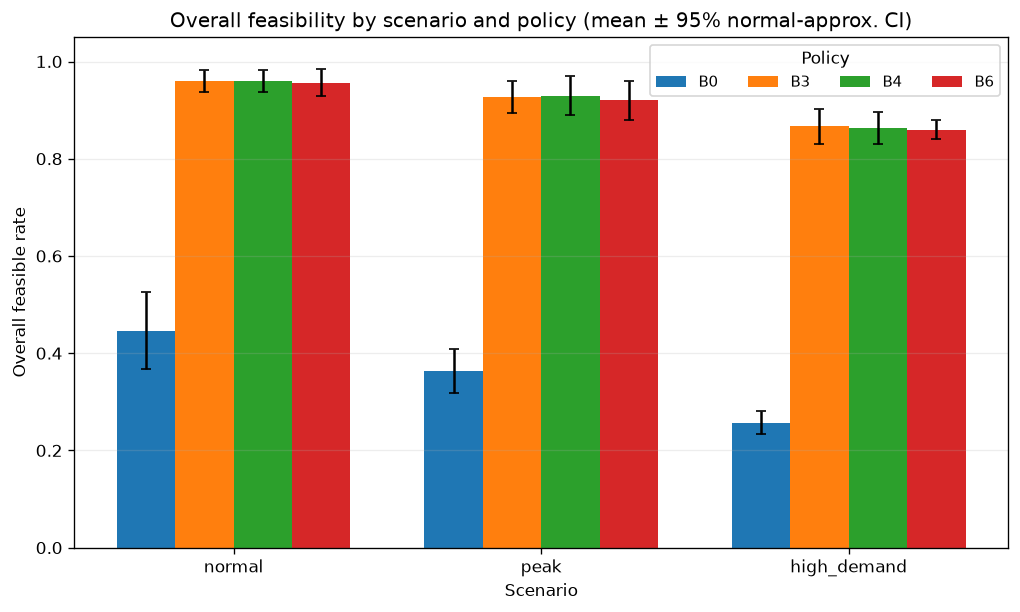

In [7]:
POLICY_ORDER = ['B0', 'B3', 'B4', 'B6']
SCENARIO_ORDER = [s for s in ['normal', 'peak', 'high_demand'] if s in metrics['scenario_id'].unique()]


def save_figure(fig, stem: str):
    png = FIGURE_DIR / f'{stem}.png'
    svg = FIGURE_DIR / f'{stem}.svg'
    fig.savefig(png, bbox_inches='tight', dpi=300)
    fig.savefig(svg, bbox_inches='tight')
    print('Saved', png.relative_to(ROOT), 'and', svg.relative_to(ROOT))


def grouped_bar(metric: str, ylabel: str, title: str, stem: str, ylim=None):
    means = metrics.groupby(['scenario_id', 'policy_id'])[metric].mean().unstack('policy_id').reindex(index=SCENARIO_ORDER, columns=POLICY_ORDER)
    sems = metrics.groupby(['scenario_id', 'policy_id'])[metric].sem().unstack('policy_id').reindex(index=SCENARIO_ORDER, columns=POLICY_ORDER)
    x = np.arange(len(SCENARIO_ORDER))
    width = 0.19
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    for i, policy in enumerate(POLICY_ORDER):
        vals = means[policy].to_numpy(float)
        err = (1.96 * sems[policy]).to_numpy(float)
        ax.bar(x + (i - 1.5) * width, vals, width, label=policy, yerr=err, capsize=3)
    ax.set_xticks(x, SCENARIO_ORDER)
    ax.set_xlabel('Scenario')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Policy', ncol=4)
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(bottom=0)
    ax.grid(axis='x', visible=False)
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()

if 'feasible_rate_overall' in metrics.columns:
    grouped_bar(
        'feasible_rate_overall', 'Overall feasible rate',
        'Overall feasibility by scenario and policy (mean ± 95% normal-approx. CI)',
        'fig01_feasible_rate', ylim=(0, 1.05)
    )


Saved report_exports/engineering_preview_smoke3rep/figures/fig02_sla_pass_rate.png and report_exports/engineering_preview_smoke3rep/figures/fig02_sla_pass_rate.svg


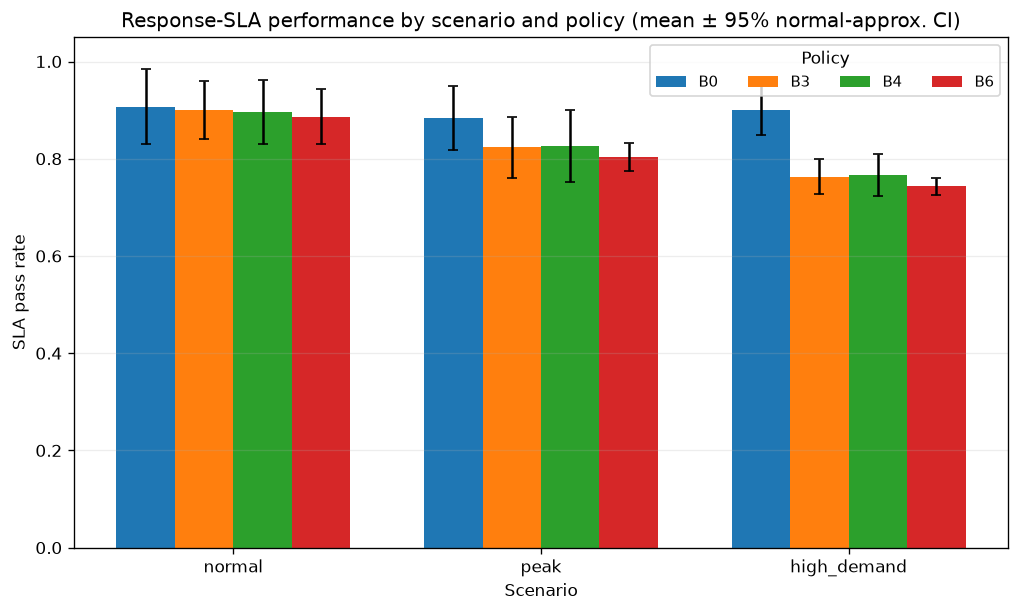

In [8]:
if 'SLA_pass_rate' in metrics.columns:
    grouped_bar(
        'SLA_pass_rate', 'SLA pass rate',
        'Response-SLA performance by scenario and policy (mean ± 95% normal-approx. CI)',
        'fig02_sla_pass_rate', ylim=(0, 1.05)
    )


Saved report_exports/engineering_preview_smoke3rep/figures/fig03_avg_response_time_min.png and report_exports/engineering_preview_smoke3rep/figures/fig03_avg_response_time_min.svg


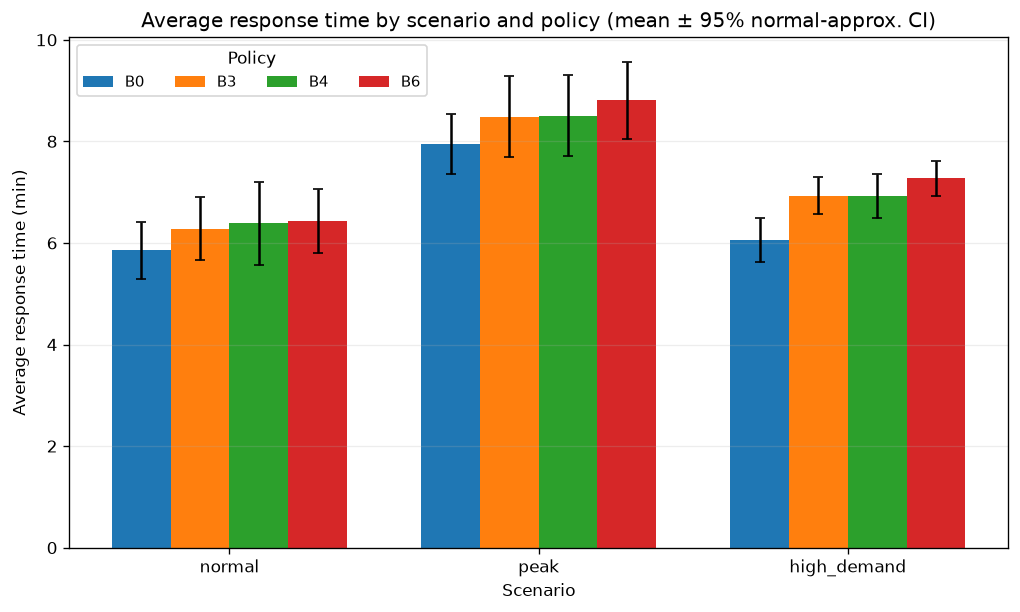

In [9]:
if 'avg_response_time_min' in metrics.columns:
    grouped_bar(
        'avg_response_time_min', 'Average response time (min)',
        'Average response time by scenario and policy (mean ± 95% normal-approx. CI)',
        'fig03_avg_response_time_min'
    )


Saved report_exports/engineering_preview_smoke3rep/figures/fig04_constraint_violations.png and report_exports/engineering_preview_smoke3rep/figures/fig04_constraint_violations.svg


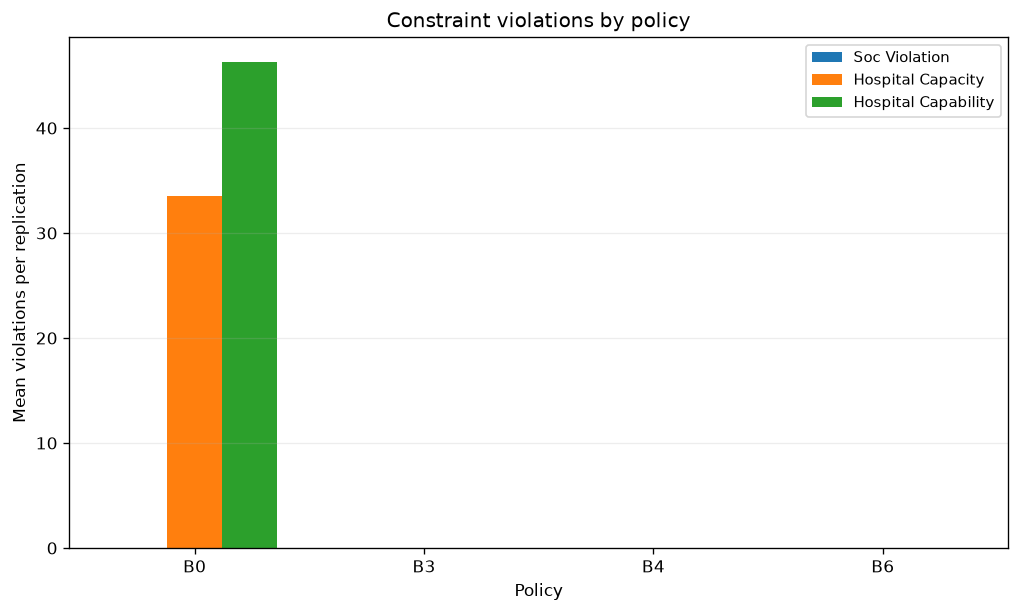

In [10]:
if violation_cols:
    v = (
        metrics.groupby('policy_id')[violation_cols]
        .mean()
        .reindex(POLICY_ORDER)
    )
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    x = np.arange(len(POLICY_ORDER))
    width = 0.24
    for i, col in enumerate(violation_cols):
        label = col.replace('_', ' ').replace(' violations', '').replace(' count', '').title()
        ax.bar(x + (i - (len(violation_cols)-1)/2) * width, v[col].to_numpy(float), width, label=label)
    ax.set_xticks(x, POLICY_ORDER)
    ax.set_xlabel('Policy')
    ax.set_ylabel('Mean violations per replication')
    ax.set_title('Constraint violations by policy')
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(axis='x', visible=False)
    fig.tight_layout()
    save_figure(fig, 'fig04_constraint_violations')
    plt.show()


Saved report_exports/engineering_preview_smoke3rep/figures/fig05_b6_paired_feasibility_effect.png and report_exports/engineering_preview_smoke3rep/figures/fig05_b6_paired_feasibility_effect.svg


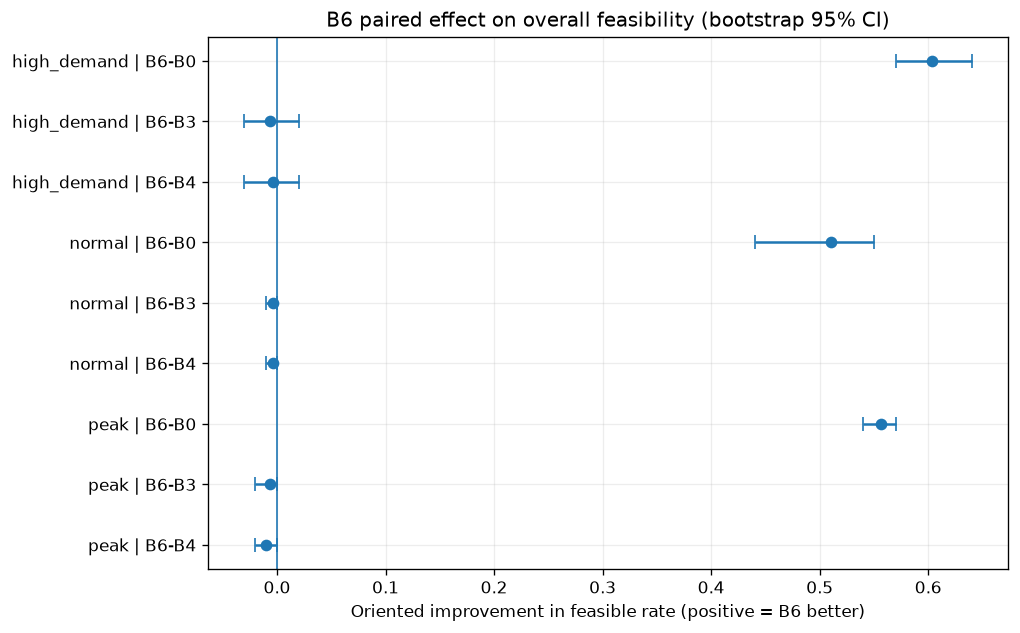

In [11]:
def paired_effect_plot(metric: str, ylabel: str, title: str, stem: str):
    d = paired_summary[paired_summary['metric'] == metric].copy()
    if d.empty:
        print('No paired data for', metric)
        return
    d['label'] = d['scenario_id'].astype(str) + ' | ' + d['comparison'].astype(str)
    d = d.sort_values(['scenario_id', 'comparison'])
    y = np.arange(len(d))
    mean = d['mean_oriented_improvement'].to_numpy(float)
    lo = d['bootstrap95_low'].to_numpy(float)
    hi = d['bootstrap95_high'].to_numpy(float)
    xerr = np.vstack([mean - lo, hi - mean])
    fig, ax = plt.subplots(figsize=(8.6, max(4.8, 0.42 * len(d) + 1.6)))
    ax.errorbar(mean, y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, linewidth=1)
    ax.set_yticks(y, d['label'])
    ax.set_xlabel(ylabel)
    ax.set_title(title)
    ax.invert_yaxis()
    fig.tight_layout()
    save_figure(fig, stem)
    plt.show()

if 'feasible_rate_overall' in paired_summary.get('metric', pd.Series(dtype=str)).values:
    paired_effect_plot(
        'feasible_rate_overall',
        'Oriented improvement in feasible rate (positive = B6 better)',
        'B6 paired effect on overall feasibility (bootstrap 95% CI)',
        'fig05_b6_paired_feasibility_effect'
    )


Saved report_exports/engineering_preview_smoke3rep/figures/fig06_b6_paired_response_time_effect.png and report_exports/engineering_preview_smoke3rep/figures/fig06_b6_paired_response_time_effect.svg


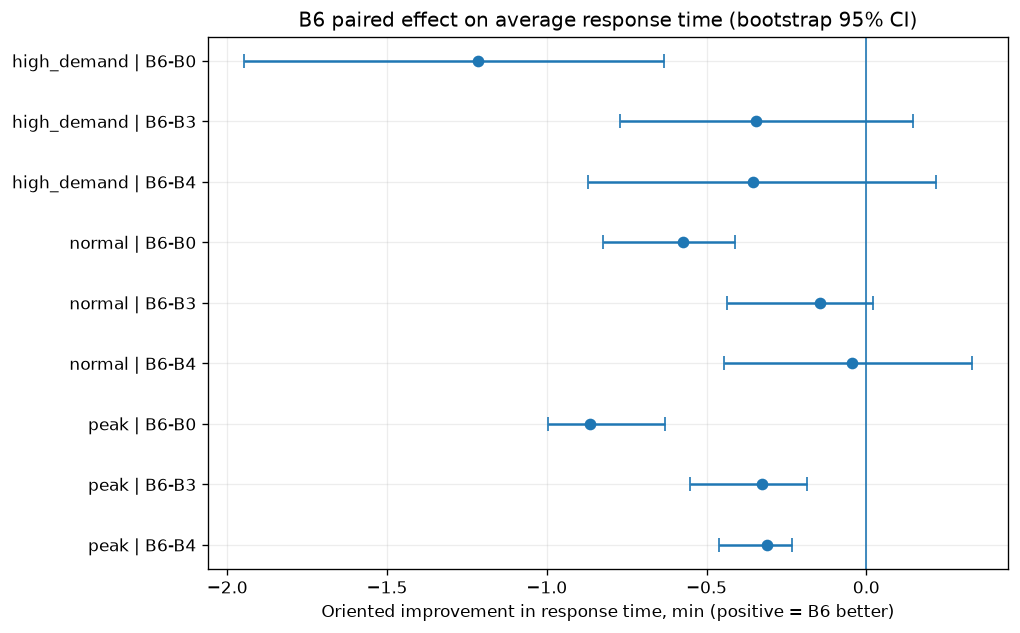

In [12]:
if 'avg_response_time_min' in paired_summary.get('metric', pd.Series(dtype=str)).values:
    paired_effect_plot(
        'avg_response_time_min',
        'Oriented improvement in response time, min (positive = B6 better)',
        'B6 paired effect on average response time (bootstrap 95% CI)',
        'fig06_b6_paired_response_time_effect'
    )


Saved report_exports/engineering_preview_smoke3rep/figures/fig07_response_feasibility_tradeoff.png and report_exports/engineering_preview_smoke3rep/figures/fig07_response_feasibility_tradeoff.svg


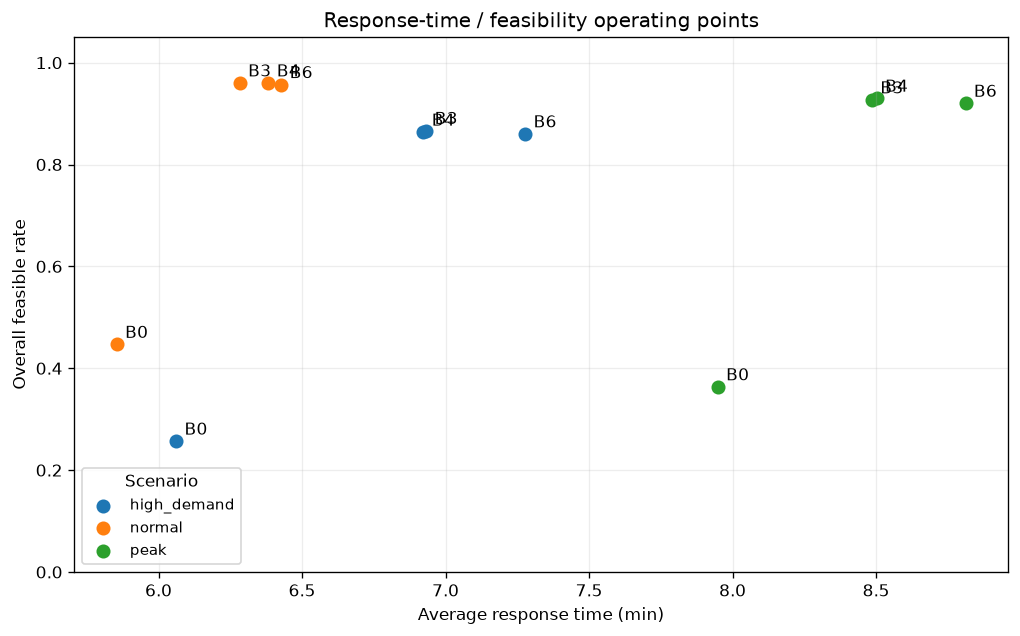

In [13]:
if {'avg_response_time_min', 'feasible_rate_overall'}.issubset(metrics.columns):
    trade = (
        metrics.groupby(['scenario_id', 'policy_id'])[['avg_response_time_min', 'feasible_rate_overall']]
        .mean()
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    for scenario, g in trade.groupby('scenario_id'):
        ax.scatter(g['avg_response_time_min'], g['feasible_rate_overall'], label=scenario, s=55)
        for _, r in g.iterrows():
            ax.annotate(r['policy_id'], (r['avg_response_time_min'], r['feasible_rate_overall']), xytext=(5, 4), textcoords='offset points')
    ax.set_xlabel('Average response time (min)')
    ax.set_ylabel('Overall feasible rate')
    ax.set_title('Response-time / feasibility operating points')
    ax.set_ylim(0, 1.05)
    ax.legend(title='Scenario')
    fig.tight_layout()
    save_figure(fig, 'fig07_response_feasibility_tradeoff')
    plt.show()


## 5. Export Manifest & Takeaways

In [14]:
table_files = sorted(p.name for p in TABLE_DIR.glob('*.csv'))
figure_files = sorted(p.name for p in FIGURE_DIR.glob('*') if p.suffix.lower() in {'.png', '.svg'})

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'source_metrics': str(SOURCE_METRICS.relative_to(ROOT)),
    'evidence_mode': EVIDENCE_MODE,
    'final_evidence_ready': final_evidence_ready,
    'n_metric_rows': int(len(metrics)),
    'scenarios': sorted(metrics['scenario_id'].astype(str).unique().tolist()),
    'policies': sorted(metrics['policy_id'].astype(str).unique().tolist()),
    'complete_pairs': int(pair_audit['complete_pair'].sum()),
    'pairs_present': int(len(pair_audit)),
    'run_summary': run_summary,
    'runtime_validation_file_present': runtime_validation_path.exists(),
    'tables': table_files,
    'figures': figure_files,
    'scientific_use_note': (
        'Final paired_30 evidence; verify calibration/sensitivity caveats before manuscript claims.'
        if final_evidence_ready else
        'Engineering preview only. Numerical values and figures must not be used as final scientific evidence.'
    ),
}
(EXPORT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=str), encoding='utf-8')

print(json.dumps({
    'evidence_mode': EVIDENCE_MODE,
    'final_evidence_ready': final_evidence_ready,
    'complete_pairs': f"{manifest['complete_pairs']}/{manifest['pairs_present']}",
    'tables_exported': len(table_files),
    'figure_files_exported': len(figure_files),
    'export_dir': str(EXPORT_DIR.relative_to(ROOT)),
}, indent=2))


{
  "evidence_mode": "engineering_preview_smoke3rep",
  "final_evidence_ready": false,
  "complete_pairs": "9/9",
  "tables_exported": 8,
  "figure_files_exported": 14,
  "export_dir": "report_exports/engineering_preview_smoke3rep"
}


### How to use in the report

1. Chỉ dùng folder `report_exports/final_paired30/` khi `manifest.json` ghi `final_evidence_ready: true`.
2. Bảng chính: `05_report_kpis.csv` và `02_paired_b6_comparisons.csv`.
3. Figure chính nên ưu tiên: feasibility, response time, paired B6 effects và trade-off plot.
4. Figure/table trong `engineering_preview_smoke3rep` chỉ phục vụ QA bố cục và pipeline.
5. Không diễn giải B6–B0 như like-for-like superiority trên cùng feasible set; ưu tiên B6–B3 và B6–B4 cho incremental comparison.